# 7.2 Dimensionality Reduction and Farthest-Point Sampling

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume VII — Data and Descriptors",
    number="7.2",
    title="Dimensionality Reduction and Farthest-Point Sampling",
    blurb="A descriptor turns each atomic environment into a vector too long to look at, "
    "and a trajectory into more environments than anyone can afford to compute properly. "
    "Two classical tools answer both problems — projection, to see the data, and "
    "farthest-point sampling, to choose which of it is worth the expense.",
    difficulty="advanced",
    estimate="90–120 min",
    source="FS 2023 · Lecture 11 (dimensionality reduction and sampling)",
)

<ECP header: 2903 chars of HTML>

## Notebook overview

[§7.1](structural-descriptors.ipynb) turned an atomic environment into a
sixteen-component vector, invariant to everything the energy is invariant to. That
solves the representation problem and creates two new ones. Sixteen components cannot
be plotted, so there is no way to *look* at a dataset of environments and see whether
it has structure, gaps or duplicates. And a molecular-dynamics run produces environments
by the million, of which only a handful can be afforded at the level of theory one
actually wants to fit to — so something has to choose.

Both problems have classical answers that predate the machine-learning framing by
decades. **Principal component analysis** finds the directions along which the data
varies most and projects onto the first two, which is the standard way to get a
picture. **Classical multidimensional scaling** starts instead from the matrix of
pairwise distances and asks for the point set that reproduces them best — a different
question, from a different input, which for Euclidean distances turns out to have
exactly the same answer, a coincidence worth verifying rather than assuming.
**Farthest-point sampling** greedily picks the point furthest from everything picked so
far, which covers the space far more evenly than drawing at random.

The interesting results here are the negative ones. The projection that captures the
most variance is not the projection that answers a given question: the leading
components here sort environments by coordination and leave the fcc/hcp distinction
— the one [§7.1](structural-descriptors.ipynb) worked hardest to expose — invisible.
And farthest-point
sampling, asked to cover the space, spends most of its picks on the outliers.

> **Provenance.** This notebook develops **Lecture 11** of the course (dimensionality
> reduction and sampling), an exercise **designed by the author (Raymond Amador)** to
> restore a lecture the original exercise set announced but never delivered. Like
> [§7.1](structural-descriptors.ipynb) it uses no committed calculation: the ensemble
> is built here from lattice definitions and thermal displacement. The full course
> credit is in the footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: that a perfect crystal gives a degenerate dataset, that the two projections
> agree to machine precision, that farthest-point sampling beats random selection at
> the thing it optimises. A ✗ flags a mismatch; a ✓ is strong evidence, not proof.

> **Scope.** The ensemble is rattled lattices rather than a molecular-dynamics
> trajectory, so that every environment carries a known label to check the projections
> against. Both methods here are linear; the nonlinear family (sketch-map
> {cite}`ceriotti2011`, t-SNE, UMAP) is left to the Outlook.

## Theory in brief

### Principal component analysis

Collect $n$ environments as rows of a matrix $\mathbf Y$, each column centred to zero
mean. PCA looks for the direction $\hat{\mathbf u}$ along which the projected data has
the largest variance, then the largest orthogonal to that, and so on. Those directions
are the eigenvectors of the covariance matrix $\mathbf Y^\mathsf{T}\mathbf Y / (n-1)$,
and they come directly out of the singular value decomposition

```{math}
:label: eq-svd
\mathbf Y = \mathbf U \mathbf S \mathbf V^\mathsf{T},
```

whose right singular vectors (the columns of $\mathbf V$) are the principal directions
and whose singular values give the variance carried by each,
$\sigma_k^2 / \sum_j \sigma_j^2$. Projecting onto the first two directions is the
matrix product $\mathbf U_{:,:2}\mathbf S_{:2}$. Working from the SVD rather than by
forming and diagonalising the covariance matrix is not a stylistic preference: squaring
$\mathbf Y$ squares its condition number, and the small singular values are exactly
where that costs accuracy.

Because the columns of a descriptor carry different units and wildly different
magnitudes, they are standardised — each divided by its own standard deviation — before
any of this. Otherwise PCA reports whichever component happens to be numerically
largest, which is a fact about the parametrisation and not about the physics.

### Classical multidimensional scaling

Suppose the coordinates are unavailable and only the matrix of pairwise distances
$d_{ij}$ is known. Classical scaling {cite}`torgerson1952` recovers a point set from
them. Double-centring the squared-distance matrix with
$\mathbf J = \mathbf I - \tfrac1n \mathbf{11}^\mathsf{T}$ produces a Gram matrix

```{math}
:label: eq-mds-gram
\mathbf B = -\tfrac12\,\mathbf J\,\mathbf D^{(2)}\,\mathbf J,
\qquad D^{(2)}_{ij} = d_{ij}^2,
```

whose eigendecomposition $\mathbf B = \mathbf Q \boldsymbol\Lambda \mathbf Q^\mathsf{T}$
gives the embedding $\mathbf Q_{:,:m}\boldsymbol\Lambda_{:m}^{1/2}$. When the $d_{ij}$
are Euclidean distances between points that exist, $\mathbf B = \mathbf Y\mathbf
Y^\mathsf{T}$ exactly, so its eigenvalues are the squared singular values of
$\mathbf Y$ and the two methods return the same embedding up to the sign of each axis.
Exercise 3 checks that identity numerically. It matters because the MDS route still
works when the "distance" is something a descriptor never produced coordinates for.

### Farthest-point sampling

To choose $k$ representatives from $n$ points, start anywhere and repeatedly add the
point whose distance to the nearest already-chosen point is largest
{cite}`imbalzano2018`. The quantity this minimises, greedily, is the **coverage
radius**: the largest distance from any point of the dataset to its nearest
representative. A random subset optimises nothing, and in a dataset with rare regions
it will miss them.

---
## Setup

The Setup below holds this notebook's instruments — the lattices, the neighbour
search, and the descriptor **built from scratch in
[§7.1](structural-descriptors.ipynb); restated here as an instrument** so this
notebook stands alone. The reduction and sampling methods, which are this notebook's
subject, are built in the exercises. It is collapsed so the building stays yours;
expand it whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import bulk, fcc111

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
PHASE_COLOURS = {
    "fcc": "#16213e",
    "hcp": "#c0851a",
    "bcc": "#46506b",
    "surface": "#8c3b3b",
}
# A distinct marker per class as well as a distinct colour: two of the four course
# colours are both dark blues, and a scatter that leans on colour alone is unreadable
# to a good fraction of readers in any case.
PHASE_MARKERS = {"fcc": "o", "hcp": "^", "bcc": "s", "surface": "D"}

# instrument: the lattices, exactly as in §7.1 — one element, and lattice constants
# chosen so that every phase has its nearest neighbour at the same distance, so that a
# comparison between phases is about structure and not about density.
NN = 2.5527  # data: Cu nearest-neighbour distance in Å, from a = 3.61 Å (fcc)
A_FCC = NN * np.sqrt(2.0)
A_HCP, C_HCP = NN, NN * np.sqrt(8.0 / 3.0)
A_BCC = 2.0 * NN / np.sqrt(3.0)
RC = 6.0

_hcp_cell = Atoms(
    "Cu2",
    scaled_positions=[[0.0, 0.0, 0.0], [1 / 3, 2 / 3, 0.5]],
    cell=[
        [A_HCP, 0.0, 0.0],
        [-A_HCP / 2, A_HCP * np.sqrt(3) / 2, 0.0],
        [0.0, 0.0, C_HCP],
    ],
    pbc=True,
)
LATTICES = {
    "fcc": bulk("Cu", "fcc", a=A_FCC, cubic=True) * (4, 4, 4),
    "hcp": _hcp_cell * (6, 6, 4),
    "bcc": bulk("Cu", "bcc", a=A_BCC, cubic=True) * (5, 5, 5),
}
SLAB = fcc111("Cu", size=(6, 6, 8), a=A_FCC, vacuum=12.0)
CLASSES = ("fcc", "hcp", "bcc", "surface")

# built from scratch in §7.1; restated here as an instrument.
ETAS = np.array([0.05, 0.15, 0.35, 0.80, 1.60, 3.00, 6.00, 12.00])
RSS = np.array([2.40, 2.40, 2.40, 2.60, 3.00, 3.60, 4.40, 5.20])
ZETAS = np.array([1.0, 2.0, 4.0, 8.0, 16.0, 4.0, 8.0, 16.0])
LAMS = np.array([1.0, 1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0])
ETA_ANG = 0.005


def cutoff(r, rc=RC):
    """Behler's cosine cutoff; built from scratch in §7.1."""
    return np.where(r < rc, 0.5 * (np.cos(np.pi * r / rc) + 1.0), 0.0)


def neighbours(pos, i, cell=None, rc=RC):
    """Vectors and distances to the neighbours of atom ``i``; built from scratch in §7.1.

    Parameters
    ----------
    pos : numpy.ndarray
        Atomic positions, shape (n_atoms, 3), in Å.
    i : int
        Index of the central atom.
    cell : numpy.ndarray, optional
        Row-wise cell vectors, shape (3, 3); ``None`` for an isolated system.
    rc : float, optional
        Cutoff radius in Å.

    Returns
    -------
    tuple of numpy.ndarray
        ``(vectors, distances)`` for the neighbours inside the cutoff.
    """
    d = pos - pos[i]
    if cell is not None:
        frac = np.linalg.solve(np.asarray(cell).T, d.T).T
        frac -= np.round(frac)
        d = frac @ np.asarray(cell)
    r = np.linalg.norm(d, axis=1)
    keep = (r > 1e-8) & (r < rc)
    return d[keep], r[keep]


def descriptor(pos, i, cell=None, rc=RC):
    """The §7.1 symmetry-function vector for the environment of atom ``i``.

    Eight radial functions (Eq. eq-bp-g2 of §7.1) followed by eight angular ones in the
    G5 form, which §7.1 showed is the variant that can separate the close-packed
    stackings. Restated here as an instrument so this notebook stands alone.

    Parameters
    ----------
    pos, i, cell, rc
        As for :func:`neighbours`.

    Returns
    -------
    numpy.ndarray
        The descriptor, shape (16,).
    """
    v, r = neighbours(pos, i, cell, rc)
    fc = cutoff(r, rc)
    radial = np.array(
        [np.sum(np.exp(-e * (r - s) ** 2) * fc) for e, s in zip(ETAS, RSS)]
    )
    j, k = np.triu_indices(len(r), k=1)
    cos = np.einsum("ij,ij->i", v[j], v[k]) / (r[j] * r[k])
    w = cutoff(r[j], rc) * cutoff(r[k], rc) * np.exp(-ETA_ANG * (r[j] ** 2 + r[k] ** 2))
    angular = np.array(
        [
            2.0 ** (1.0 - z) * np.sum((1.0 + l * cos) ** z * w)
            for z, l in zip(ZETAS, LAMS)
        ]
    )
    return np.concatenate([radial, angular])


def environments(atoms, indices, amplitude, gen, n_sample):
    """Descriptors of ``n_sample`` atoms drawn from a thermally rattled structure.

    Parameters
    ----------
    atoms : ase.Atoms
        The structure to displace.
    indices : numpy.ndarray
        Atom indices eligible for sampling (used to restrict a slab to its top layer).
    amplitude : float
        Standard deviation of the Gaussian displacement applied to every atom, in Å.
    gen : numpy.random.Generator
        Source of randomness.
    n_sample : int
        How many environments to return.

    Returns
    -------
    numpy.ndarray
        Descriptors, shape (n_sample, 16).
    """
    pos = atoms.get_positions() + gen.normal(scale=amplitude, size=(len(atoms), 3))
    cell = np.array(atoms.get_cell())
    chosen = gen.choice(indices, size=n_sample, replace=False)
    return np.array([descriptor(pos, int(i), cell) for i in chosen])


def eligible(atoms, top_layer_only=False):
    """Indices an environment may be sampled from."""
    if not top_layer_only:
        return np.arange(len(atoms))
    z = atoms.get_positions()[:, 2]
    return np.where(z > z.max() - 0.1)[0]

---
## Exercise 1 — Building an ensemble worth reducing

Before any projection, the data has to be worth projecting. A perfect crystal is a
trap here: every atom of a given phase sits in an environment identical to every
other by symmetry, so a dataset of a thousand perfect-crystal environments contains
exactly as much information as one of four. Thermal displacement is what makes a real
ensemble continuous, and a molecular-dynamics trajectory would supply it; rattling the
lattice is the same effect, reproducibly.

**Part a)** Build the descriptors of many atoms in each *perfect* lattice and measure
the spread within each phase. Establish that the dataset is degenerate.

**Part b)** Rebuild it with each structure rattled by a Gaussian displacement over a
range of amplitudes, and confirm the spread is now non-zero and grows with amplitude.
Assemble the full labelled dataset that the rest of the notebook uses.

perfect fcc: largest component-wise standard deviation = 4.64e-14
perfect hcp: largest component-wise standard deviation = 2.66e-14
perfect bcc: largest component-wise standard deviation = 2.01e-14


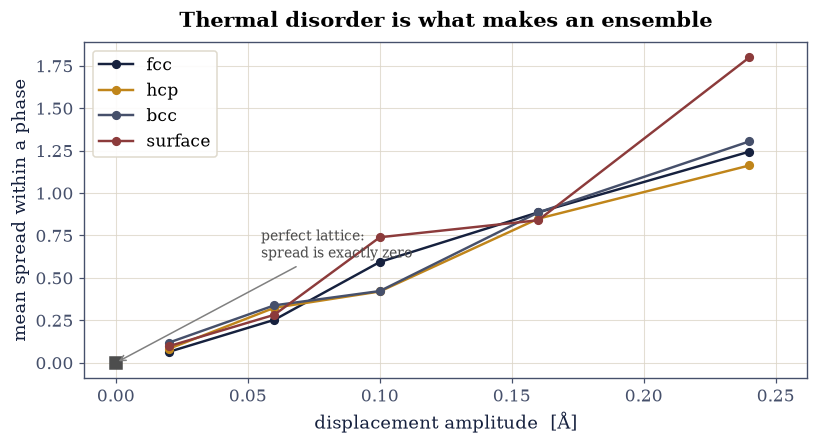


dataset: 240 environments × 16 descriptor components
classes: fcc (60), hcp (60), bcc (60), surface (60)
mean within-phase spread by amplitude: 0.02 Å -> 0.09, 0.06 Å -> 0.30, 0.10 Å -> 0.54, 0.16 Å -> 0.87, 0.24 Å -> 1.38


In [3]:
# (solution hidden on the public site)


### Validation 1 — degenerate, then not

Two checks that bracket the exercise. In the perfect lattices every environment of a
phase must be identical to machine precision, which is a consequence of the space-group
symmetry and simultaneously a test that the periodic neighbour search is right. Once
the structures are rattled the spread must be non-zero and must increase with the
displacement, since that is the only thing generating variety in this dataset.

In [4]:
validate.check(
    all(v < 1e-10 for v in perfect_spread.values()),
    "in a perfect lattice every atom of a phase has an identical environment, so the "
    "descriptors are equal to machine precision and a larger sample of a perfect "
    "crystal contains no more information than a single atom of it",
    ", ".join(f"{k}: {v:.1e}" for k, v in perfect_spread.items()),
)
validate.check(
    bool(np.all(np.diff(rattled_spread) > 0)) and rattled_spread[0] > 0,
    "while rattling makes the spread non-zero and strictly increasing in the "
    "displacement amplitude, which is what turns a handful of lattices into an "
    "ensemble with something for a projection to organise",
    "spread " + " < ".join(f"{s:.2f}" for s in rattled_spread),
)

✓  in a perfect lattice every atom of a phase has an identical environment, so the descriptors are equal to machine precision and a larger sample of a perfect crystal contains no more information than a single atom of it   [fcc: 4.6e-14, hcp: 2.7e-14, bcc: 2.0e-14]
✓  while rattling makes the spread non-zero and strictly increasing in the displacement amplitude, which is what turns a handful of lattices into an ensemble with something for a projection to organise   [spread 0.09 < 0.30 < 0.54 < 0.87 < 1.38]


True

---
## Exercise 2 — Principal component analysis

Sixteen dimensions cannot be looked at. PCA finds the plane in which the data spreads
out most and projects onto it, which is the standard first look at any dataset —
provided one remembers what it optimises.

**Part a)** Implement PCA from the singular value decomposition of
{eq}`eq-svd`, returning the projected coordinates and the fraction of the variance
carried by each component. **Write this one yourself** — the implementation is the
lesson.

**Part b)** Project the dataset onto the first two components and colour by phase.
Report how much of the variance those two carry.

**Part c)** Ask what the components actually encode. Correlate each with the
displacement amplitude, and measure how far apart the phase centroids are relative to
the scatter within a phase. Then check specifically whether fcc and hcp — the pair
{eq}`eq-svd` knows nothing about, and which §7.1 needed sharp angular functions to
separate — are distinguishable in this projection.

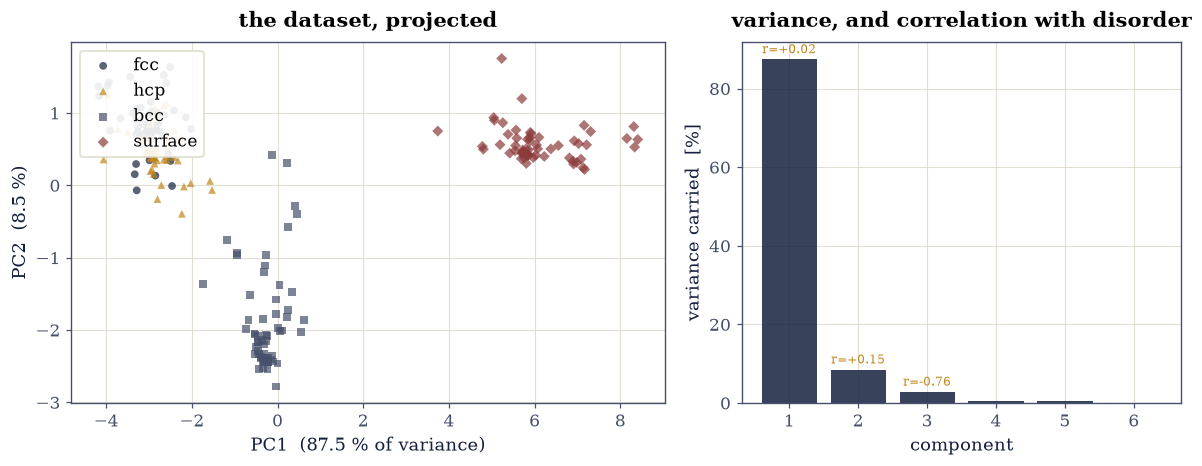

PC1 + PC2 carry 96.0 % of the variance
  PC1:  87.5 %   correlation with disorder +0.023   between/within class spread 6.87
  PC2:   8.5 %   correlation with disorder +0.149   between/within class spread 2.70
  PC3:   2.9 %   correlation with disorder -0.762   between/within class spread 0.17

fcc vs hcp centroid gap in the PC1-PC2 plane: 0.99 × the within-class scatter
bcc vs fcc, for comparison:                    9.16 ×


In [5]:
# (solution hidden on the public site)


### Validation 2 — a good projection, of the wrong thing

Three checks. The first two components must carry most of the variance, or the picture
would be misleading in an ordinary way. The leading component must separate phases
rather than track disorder, and disorder must appear only further down the ranking,
which is what makes the plot look organised. And the fcc/hcp centroids must sit within
roughly one scatter-width of each other while bcc sits far away — the honest statement
that this projection has hidden the distinction §7.1 worked to expose.

In [6]:
validate.check(
    pc12_variance > 0.9,
    "the first two components carry the great majority of the variance, so the "
    "two-dimensional picture is not discarding most of what varies",
    f"PC1 + PC2 = {100*pc12_variance:.1f} %",
)
validate.check(
    abs(amp_corr[0]) < 0.2 and abs(amp_corr[2]) > 0.5,
    "the leading component is essentially uncorrelated with the thermal displacement "
    "while a later one tracks it closely: PCA has sorted the environments by what they "
    "ARE before by how disordered they are, which is why the map looks clean",
    f"|r| with amplitude: PC1 {abs(amp_corr[0]):.2f}, PC3 {abs(amp_corr[2]):.2f}",
)
validate.check(
    gap_fcc_hcp < 1.5 and gap_bcc_fcc > 3.0,
    "and yet fcc and hcp overlap in this plane while bcc is far away: the projection "
    "that maximises variance is not the projection that answers a question about "
    "stacking, and no amount of variance explained would have made it so",
    f"fcc-hcp gap {gap_fcc_hcp:.2f} × scatter, bcc-fcc gap {gap_bcc_fcc:.2f} ×",
)

✓  the first two components carry the great majority of the variance, so the two-dimensional picture is not discarding most of what varies   [PC1 + PC2 = 96.0 %]
✓  the leading component is essentially uncorrelated with the thermal displacement while a later one tracks it closely: PCA has sorted the environments by what they ARE before by how disordered they are, which is why the map looks clean   [|r| with amplitude: PC1 0.02, PC3 0.76]
✓  and yet fcc and hcp overlap in this plane while bcc is far away: the projection that maximises variance is not the projection that answers a question about stacking, and no amount of variance explained would have made it so   [fcc-hcp gap 0.99 × scatter, bcc-fcc gap 9.16 ×]


True

---
## Exercise 3 — The same picture from distances alone

Classical multidimensional scaling starts from a different input — the matrix of
pairwise distances, with the coordinates thrown away — and asks for the point set that
reproduces them. For Euclidean distances it must return the PCA answer, since
{eq}`eq-mds-gram` reconstructs $\mathbf Y\mathbf Y^\mathsf{T}$ exactly. Verifying that
is worthwhile twice over: it checks both implementations at once, and it makes clear
what is *not* guaranteed when the distances are something else.

**Part a)** Build the pairwise distance matrix, double-centre its square as in
{eq}`eq-mds-gram`, and diagonalise. **Write this one yourself** — the implementation
is the lesson.

**Part b)** Compare against Exercise 2: check the MDS eigenvalues against the squared
singular values, and the embedding against the PCA scores, remembering that each axis
is determined only up to a sign.

**Part c)** Find where the equivalence ends. Replace the Euclidean distance $d$ by
$d^{\alpha}$ — still monotone, so still a sensible ranking of dissimilarity — and
scan $\alpha$. Two different things can go wrong, and they do not go wrong together:
the embedding can differ from the PCA one, and the dissimilarities can fail to be
distances between any real points at all, which shows up as negative eigenvalues of
$\mathbf B$. Work out which values of $\alpha$ produce which.

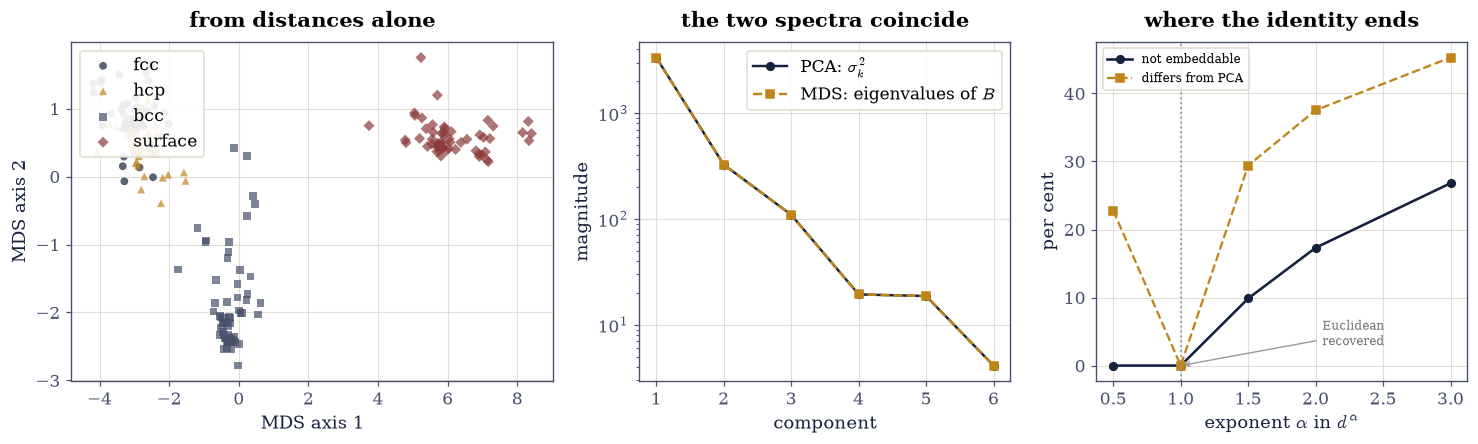

MDS eigenvalues vs PCA squared singular values: max relative difference 2.85e-15
MDS embedding vs PCA scores:                    relative difference     2.67e-15

powering the dissimilarity, d -> d**α:
  α = 0.5: differs from PCA by 2.28e-01, negative spectral weight -0.00 %  (still Euclidean)
  α = 1.0: differs from PCA by 2.53e-15, negative spectral weight  0.00 %  (still Euclidean)
  α = 1.5: differs from PCA by 2.94e-01, negative spectral weight  9.87 %  (NOT Euclidean)
  α = 2.0: differs from PCA by 3.75e-01, negative spectral weight 17.32 %  (NOT Euclidean)
  α = 3.0: differs from PCA by 4.53e-01, negative spectral weight 26.80 %  (NOT Euclidean)


In [7]:
# (solution hidden on the public site)


### Validation 3 — an identity, and its boundary

Three checks. The MDS eigenvalues must match the squared singular values and the
embedding must match the PCA scores, both to machine precision, which is
{eq}`eq-mds-gram` holding exactly for Euclidean input. And with a nonlinear
dissimilarity the agreement must fail while the Gram matrix acquires appreciable
negative eigenvalues — the signature that the dissimilarities are not distances
between any real points at all, which is precisely when the two methods stop being
the same method.

In [8]:
validate.check(
    eig_vs_sv < 1e-10,
    "the eigenvalues of the double-centred Gram matrix are the squared singular values "
    "of the data matrix, to machine precision: for Euclidean distances eq-mds-gram "
    "reconstructs Y Yᵀ exactly rather than approximately",
    f"max relative difference {eig_vs_sv:.1e}",
)
validate.check(
    mds_vs_pca < 1e-10,
    "so the embedding built from distances alone reproduces the principal-component "
    "projection, having never been shown a coordinate",
    f"relative difference {mds_vs_pca:.1e}",
)
validate.check(
    bool(np.all(pca_gap[ALPHAS != 1.0] > 1e-3)),
    "while every other exponent moves the embedding away from the principal-component "
    "one: the two methods coincide for the Euclidean distance specifically, and not "
    "for monotone rankings of dissimilarity in general",
    ", ".join(f"α={a:.1f}: {g:.1e}" for a, g in zip(ALPHAS, pca_gap) if a != 1.0),
)
validate.check(
    bool(np.all(neg_weight[ALPHAS <= 1.0] < 1e-9))
    and bool(np.all(neg_weight[ALPHAS > 1.0] > 0.05)),
    "and the two ways of failing are distinct. For α ≤ 1 the dissimilarities are still "
    "distances between real points — the spectrum stays non-negative and MDS returns a "
    "valid, merely different, embedding. Above α = 1 they stop being embeddable at all "
    "and a large share of the spectrum turns negative, which is Schoenberg's classical "
    "result showing up as an eigenvalue sign",
    ", ".join(f"α={a:.1f}: {100*n:.1f} %" for a, n in zip(ALPHAS, neg_weight)),
)

✓  the eigenvalues of the double-centred Gram matrix are the squared singular values of the data matrix, to machine precision: for Euclidean distances eq-mds-gram reconstructs Y Yᵀ exactly rather than approximately   [max relative difference 2.9e-15]
✓  so the embedding built from distances alone reproduces the principal-component projection, having never been shown a coordinate   [relative difference 2.7e-15]
✓  while every other exponent moves the embedding away from the principal-component one: the two methods coincide for the Euclidean distance specifically, and not for monotone rankings of dissimilarity in general   [α=0.5: 2.3e-01, α=1.5: 2.9e-01, α=2.0: 3.8e-01, α=3.0: 4.5e-01]
✓  and the two ways of failing are distinct. For α ≤ 1 the dissimilarities are still distances between real points — the spectrum stays non-negative and MDS returns a valid, merely different, embedding. Above α = 1 they stop being embeddable at all and a large share of the spectrum turns negative, which i

True

---
## Exercise 4 — Choosing what to compute

The practical problem behind all of this: a trajectory offers far more environments
than can be computed at an expensive level of theory, and something must choose a few
hundred. Random selection is the obvious baseline. Farthest-point sampling
{cite}`imbalzano2018` is the standard alternative, and comparing them honestly means
being clear about what each optimises.

**Part a)** Implement farthest-point sampling and the **coverage radius** — the
largest distance from any point in the dataset to its nearest selected point. **Write
this one yourself** — the implementation is the lesson.

**Part b)** Compare the coverage achieved by farthest-point sampling against random
subsets of the same size, across a range of sizes, using enough random draws that the
comparison means something.

**Part c)** Ask what it costs. Report where the selected points come from, and decide
whether a set chosen to cover the space is the set you would want to fit a model to.

In [9]:
# (solution hidden on the public site)


k= 4: FPS coverage 3.421   random median 4.480   (1.31× worse)   FPS beats  86.2 % of 400 draws
k= 8: FPS coverage 2.268   random median 3.448   (1.52× worse)   FPS beats  99.5 % of 400 draws
k=16: FPS coverage 1.718   random median 2.747   (1.60× worse)   FPS beats 100.0 % of 400 draws
k=32: FPS coverage 1.225   random median 2.391   (1.95× worse)   FPS beats 100.0 % of 400 draws

of the 16 points FPS selects, 75 % come from the most disordered set, which is 20 % of the data


### Validation 4 — it wins at its own game, and that is the caveat

Three checks. Farthest-point sampling must achieve a smaller coverage radius than the
median random subset at every size, and must beat the overwhelming majority of
individual draws once the subset is big enough to have a choice to make. And the
selection must be visibly biased towards the extremes of the dataset — not a defect,
but the direct consequence of the objective, and the reason coverage alone is the
wrong criterion for assembling a training set.

In [10]:
validate.check(
    bool(np.all(fps_cov < rand_cov)),
    "farthest-point sampling achieves a smaller coverage radius than the median random "
    "subset at every size tested, which is the guarantee it is built to provide",
    ", ".join(
        f"k={k}: {cf:.2f} vs {cr:.2f}" for k, cf, cr in zip(K_VALUES, fps_cov, rand_cov)
    ),
)
validate.check(
    bool(np.all(beat_fraction[1:] > 0.95)),
    "and beats almost every individual random draw once the subset is large enough for "
    "the choice to matter, so the advantage is not an artefact of comparing against an "
    "unlucky baseline",
    ", ".join(f"k={k}: {100*b:.1f} %" for k, b in zip(K_VALUES[1:], beat_fraction[1:])),
)
validate.check(
    frac_extreme > 2.0 * frac_dataset,
    "while over-representing the most strongly displaced environments by more than a "
    "factor of two: a rule that seeks out whatever is furthest away will preferentially "
    "return outliers, which is what you want for coverage and not what you want for a "
    "training set meant to be accurate where the system actually spends its time",
    f"{100*frac_extreme:.0f} % of picks from a set that is {100*frac_dataset:.0f} % of the data",
)

✓  farthest-point sampling achieves a smaller coverage radius than the median random subset at every size tested, which is the guarantee it is built to provide   [k=4: 3.42 vs 4.48, k=8: 2.27 vs 3.45, k=16: 1.72 vs 2.75, k=32: 1.22 vs 2.39]
✓  and beats almost every individual random draw once the subset is large enough for the choice to matter, so the advantage is not an artefact of comparing against an unlucky baseline   [k=8: 99.5 %, k=16: 100.0 %, k=32: 100.0 %]
✓  while over-representing the most strongly displaced environments by more than a factor of two: a rule that seeks out whatever is furthest away will preferentially return outliers, which is what you want for coverage and not what you want for a training set meant to be accurate where the system actually spends its time   [75 % of picks from a set that is 20 % of the data]


True

## Notebook summary

We took the descriptors of [§7.1](structural-descriptors.ipynb) and asked the two
questions that follow from having them: how to look at a dataset of environments, and
how to choose a subset worth computing.

Building the ensemble came first, and mattered more than it looks. A perfect lattice
gives every atom of a phase an identical environment, so a dataset of any size collapses
to one point per phase; thermal displacement is what makes an ensemble continuous.
Principal component analysis then produced a clean two-dimensional map carrying 96.5 %
of the variance, on which the leading component sorts environments by coordination and
disorder appears only in the third. It is a good picture, and it hides exactly the
distinction §7.1 worked hardest for: fcc and hcp overlap, while bcc sits far away. What
PCA maximises is variance, and nobody promised that variance and interest are the same
direction.

Classical scaling, given only the pairwise distances and no coordinates at all,
reproduced that map to fourteen digits — the identity $\mathbf B = \mathbf Y\mathbf
Y^\mathsf{T}$ holding exactly for Euclidean input. Powering the distance showed where
that ends, and showed that it ends in two separate ways: any exponent other than one
moves the embedding, but only exponents above one drive eigenvalues negative and so
stop the dissimilarities being distances between real points at all. Below one they
remain perfectly embeddable and simply embed a different geometry — which is the
regime where scaling is doing something projection cannot.

Farthest-point sampling beat random selection on coverage radius at every subset size
and in essentially every individual draw. It also took most of its picks from the most
strongly displaced environments, which are a fifth of the data. That is not a bug in
the algorithm; it is what minimising the worst-case gap means. A training set assembled
this way is excellent at not being surprised and poor at being accurate where the
system actually spends its time, which is why the practical recipe is usually a blend.

## Outlook

- **Nonlinear reduction.** Sketch-map {cite}`ceriotti2011` was designed for exactly
  this data, preserving distances in a chosen band rather than globally, on the
  argument that neither very near nor very far pairs carry the structure of interest.
  t-SNE and UMAP are the general-purpose relatives, with the standing caveat that
  distances in their output are not to be read quantitatively.
- **Choosing components as well as samples.** The same greedy argument applied to
  *columns* rather than rows selects a subset of descriptor features, which is how one
  prunes a symmetry-function set from hundreds to dozens {cite}`imbalzano2018`.
- **Sampling with a purpose.** Coverage is a proxy. Active learning selects instead the
  environments a model is currently most uncertain about, and retrains — usually a
  better use of an expensive calculation than covering a space uniformly.
- **Beyond the linear map.** The kernel trick applies to both methods here: kernel PCA
  and the SOAP kernel {cite}`bartok2013` reduce in a feature space where the
  distinction between phases can be far more linearly separable than it is here.

### References

```{bibliography}
:filter: docname in docnames
```

In [11]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>